# WEATHER DATA ANALYSIS

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import requests

In [3]:
API_KEY = "5b6eefa98cc33b0d547a54b0dda17f94"

In [23]:
def get_weather(city):
    url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"
    response = requests.get(url)
    data = response.json()
    
    # Handle error (important)
    if data["cod"] != 200:
        print(f"Cannot find data for {city}")
        return None
    
    return {
        "City": city,
        "Temperature": data["main"]["temp"],
        "Humidity": data["main"]["humidity"],
        "Pressure": data["main"]["pressure"],
        "Wind Speed": data["wind"]["speed"]
    }

In [43]:
city_input = input("Enter cities (comma-separated): ")

if city_input.strip() == "":
    print("⚠️ Please enter at least one city")
else:
    cities = [city.strip().title() for city in city_input.split(",")]

In [45]:
weather_list = []

for city in cities:
    result = get_weather(city)
    if result:
        weather_list.append(result)

df = pd.DataFrame(weather_list)

print("\nDataFrame:")
df


DataFrame:


,City,Temperature,Humidity,Pressure,Wind Speed
0,Mumbai,30.99,70,1006,4.63
1,Delhi,41.05,14,997,2.57


### DATA CLEANING

In [46]:
print(df.isnull().sum())

df = df.dropna()

df

City           0
Temperature    0
Humidity       0
Pressure       0
Wind Speed     0
dtype: int64


,City,Temperature,Humidity,Pressure,Wind Speed
0,Mumbai,30.99,70,1006,4.63
1,Delhi,41.05,14,997,2.57


In [47]:
df.describe()

,Temperature,Humidity,Pressure,Wind Speed
count,2.000000,2.00000,2.000000,2.00000
mean,36.020000,42.00000,1001.500000,3.60000
std,7.113494,39.59798,6.363961,1.45664
min,30.990000,14.00000,997.000000,2.57000
25%,33.505000,28.00000,999.250000,3.08500
50%,36.020000,42.00000,1001.500000,3.60000
75%,38.535000,56.00000,1003.750000,4.11500
max,41.050000,70.00000,1006.000000,4.63000


In [48]:
if df.empty:
    print("❌ No data available. Check API key or city names.")

In [49]:
if not df.empty:
    # Hottest city
    hottest = df.loc[df['Temperature'].idxmax()]
    print("🔥 Hottest City:", hottest["City"])

    # Most humid city
    humid = df.loc[df['Humidity'].idxmax()]
    print("💧 Most Humid City:", humid["City"])

🔥 Hottest City: Delhi
💧 Most Humid City: Mumbai


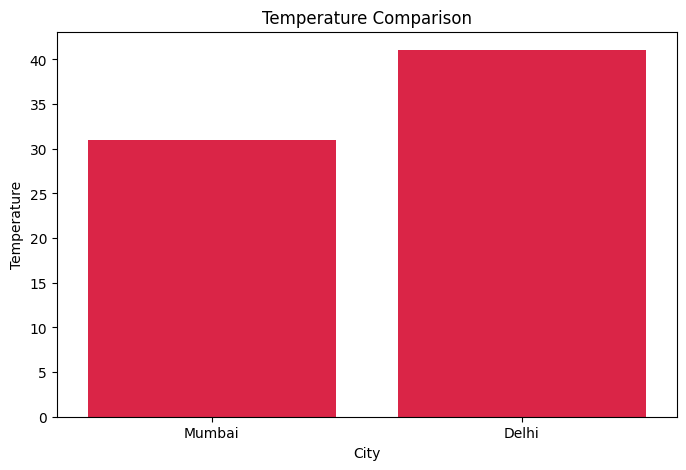

In [50]:
plt.figure(figsize=(8,5))
sns.barplot(x='City', y='Temperature',color="#F80734", data=df)
plt.title("Temperature Comparison")
plt.show()

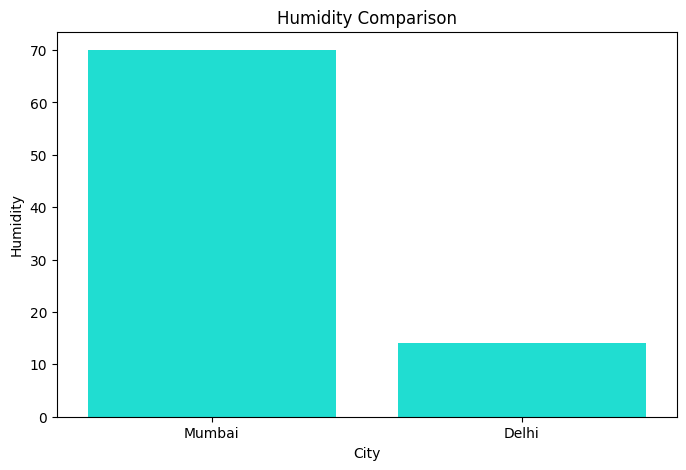

In [51]:
plt.figure(figsize=(8,5))
sns.barplot(x='City', y='Humidity',color="#00FDEC", data=df)
plt.title("Humidity Comparison")
plt.show()

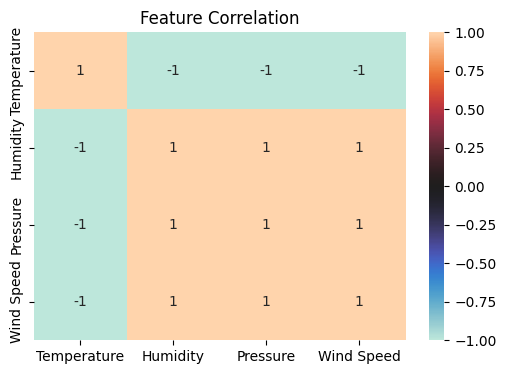

In [52]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="icefire")
plt.title("Feature Correlation")
plt.show()

In [53]:
print("📊 Insights:")

print(f"- {hottest['City']} has the highest temperature.")
print(f"- {humid['City']} has the highest humidity.")
print("- Temperature and humidity relationship can be seen in heatmap.")

📊 Insights:
- Delhi has the highest temperature.
- Mumbai has the highest humidity.
- Temperature and humidity relationship can be seen in heatmap.
